<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/VGG_16_Random_Forest_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import itertools
import joblib
from PIL import Image
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print('Modules loaded.')


Modules loaded.


In [ ]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)
# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)

In [ ]:
df

,filepaths,labels
0,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
1,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
2,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
3,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
4,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
...,...,...
1573,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1574,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1575,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1576,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant


In [ ]:
# Split the data into training and testing sets
strat = df['labels']
train_df, test_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=123, stratify=strat)

In [ ]:
test_df

,filepaths,labels
133,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
481,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
372,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
605,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
571,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
...,...,...
1444,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1413,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
726,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
218,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal


In [ ]:
# Load and preprocess images
def load_and_preprocess_images(filepaths):
    images = []
    for filepath in filepaths:
        img = Image.open(filepath).convert('RGB')  # Load image
        img = img.resize((224, 224))  # Resize image
        img_array = img_to_array(img)  # Convert to array
        images.append(img_array)
    return np.array(images)

In [ ]:
# Load training and testing images
X_train = load_and_preprocess_images(train_df['filepaths'].values)
y_train = train_df['labels'].values
X_test = load_and_preprocess_images(test_df['filepaths'].values)
y_test = test_df['labels'].values

In [ ]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [ ]:
# Load VGG16 model for feature extraction
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')

# Extract features
X_train_features = vgg_model.predict(X_train)
X_test_features = vgg_model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 834s 21s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 203s 20s/step


In [ ]:
# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=500, random_state=42)
rf_classifier.fit(X_train_features, y_train_encoded)

# Make predictions
y_pred = rf_classifier.predict(X_test_features)

In [ ]:
# Evaluate the model
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.83      0.99      0.90       179
   malignant       0.98      0.73      0.84        84
      normal       0.97      0.74      0.84        53

    accuracy                           0.88       316
   macro avg       0.93      0.82      0.86       316
weighted avg       0.89      0.88      0.87       316



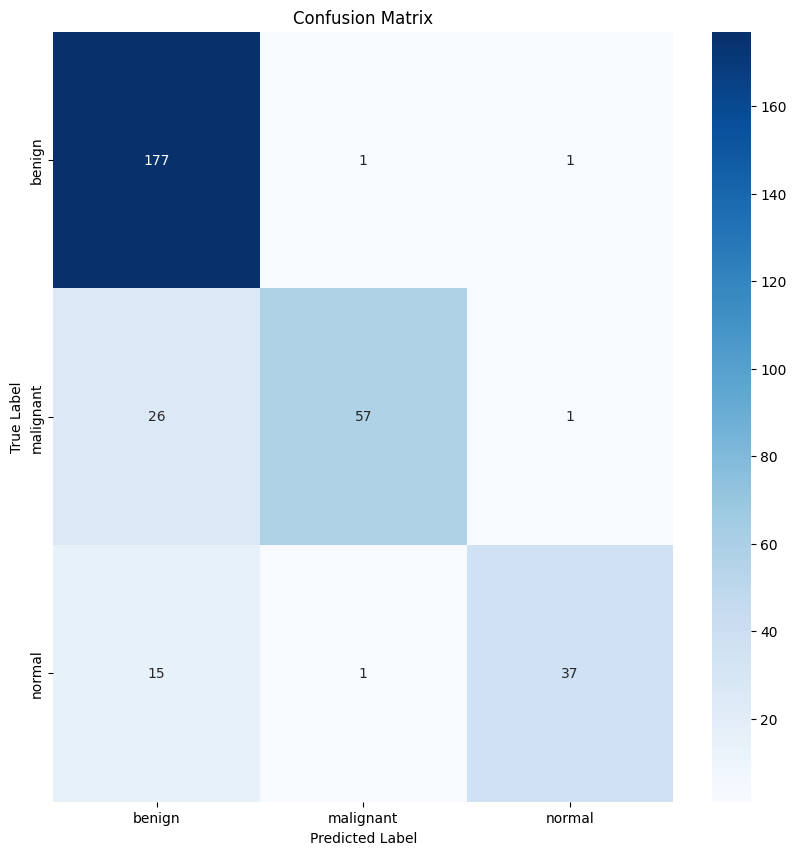

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Save the model (optional)
import joblib
joblib.dump(rf_classifier, 'random_forest_vgg16_model.pkl')

['random_forest_vgg16_model.pkl']